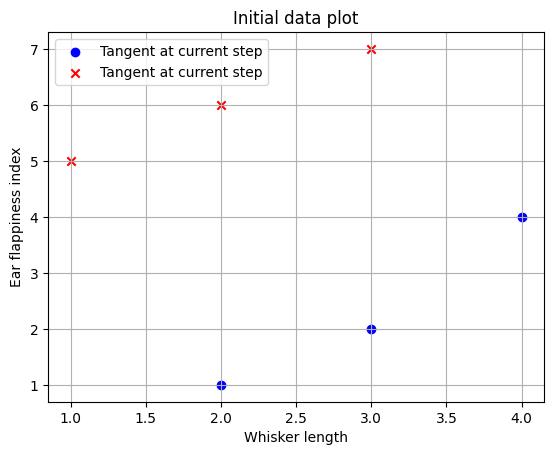

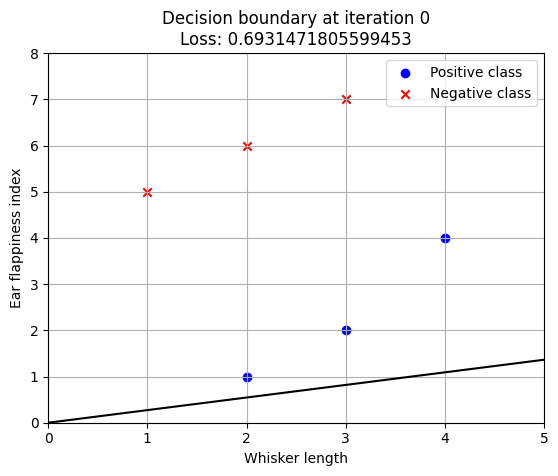

Iteration 0: Theta=[ 0.          0.025      -0.09166667], Loss=0.6931471805599453


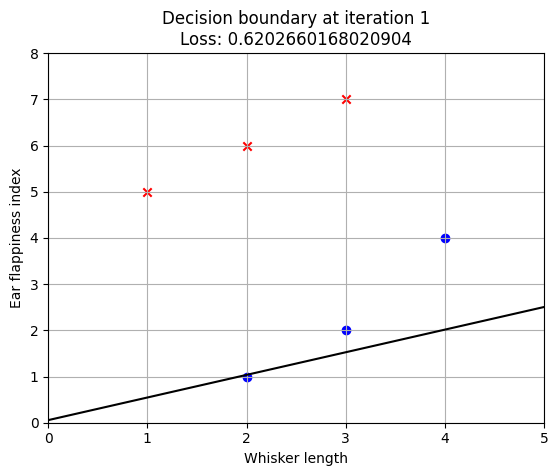

Iteration 1: Theta=[ 0.00784781  0.06887779 -0.14060525], Loss=0.6202660168020904


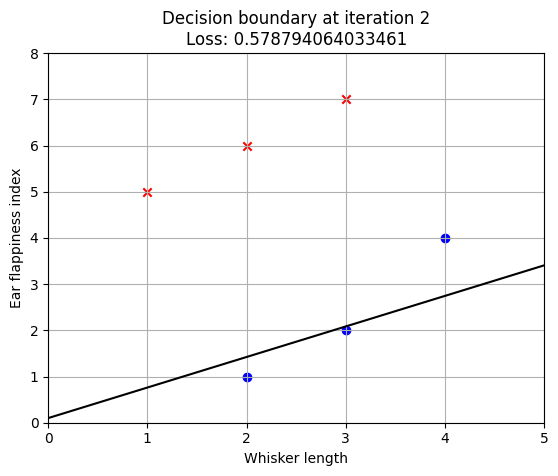

Iteration 2: Theta=[ 0.01764134  0.11658362 -0.17629863], Loss=0.578794064033461


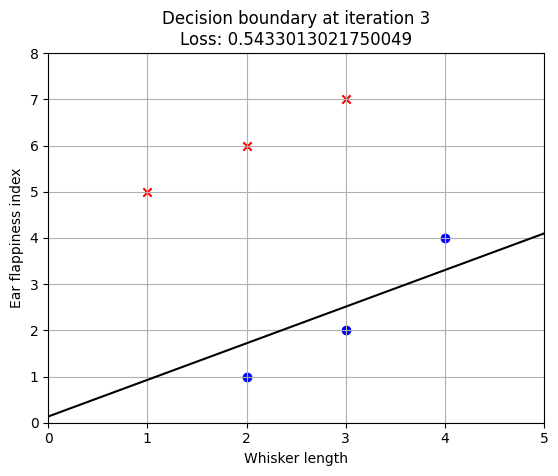

Iteration 3: Theta=[ 0.02775584  0.16401158 -0.20689154], Loss=0.5433013021750049


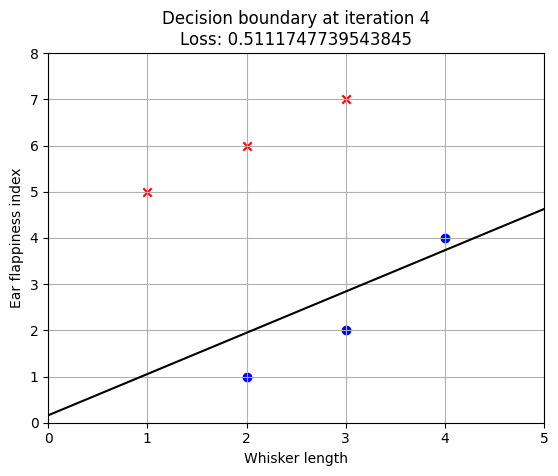

Iteration 4: Theta=[ 0.03768945  0.20992896 -0.23499581], Loss=0.5111747739543845


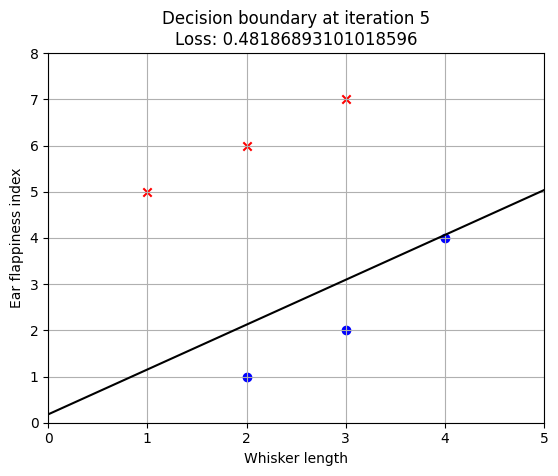

Iteration 5: Theta=[ 0.04728565  0.25399034 -0.26154053], Loss=0.48186893101018596


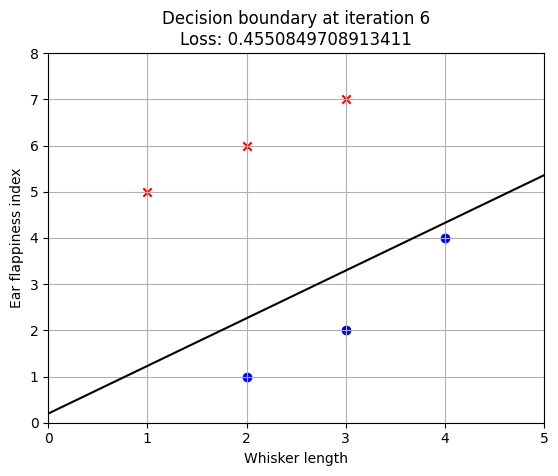

Iteration 6: Theta=[ 0.0565048   0.29615111 -0.28688777], Loss=0.4550849708913411


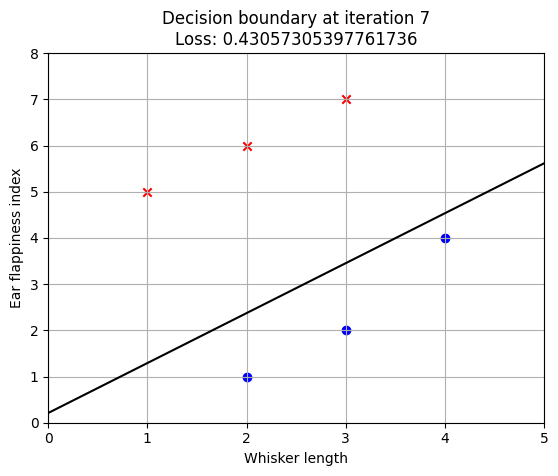

Iteration 7: Theta=[ 0.06534809  0.33647087 -0.31119923], Loss=0.43057305397761736


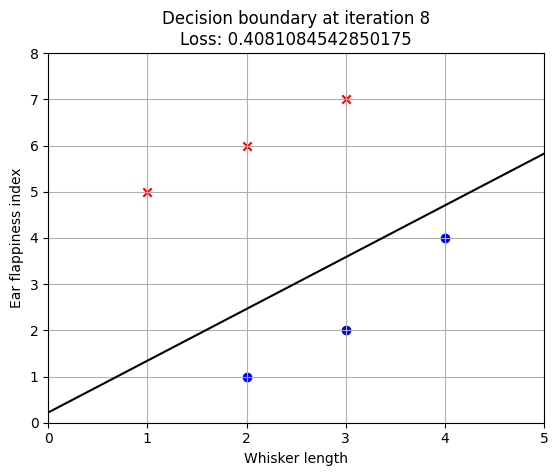

Iteration 8: Theta=[ 0.07383072  0.37504349 -0.3345636 ], Loss=0.4081084542850175


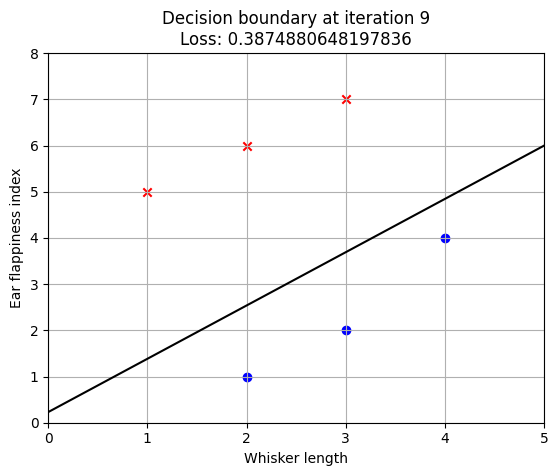

Iteration 9: Theta=[ 0.08197221  0.41197135 -0.35704216], Loss=0.3874880648197836


In [28]:
import numpy as np
import matplotlib.pyplot as plt

# define the sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z)) 

# loss function : log likelihood
def compute_loss(y , hx):
    return -np.mean(y*np.log(hx) + (1-y)* np.log(1-hx))

# gradient of the loss
def compute_gradient(X,y,hx):
    return np.dot(X.T,(hx-y)/y.shape[0])

X= np.array([
    [2,1]
    ,[3,2]
    ,[4,4] # positive samples
    ,[1,5]
    ,[2,6]
    ,[3,7] # negative samples
])

y = np.array([1,1,1,0,0,0]) # labels

# plot initial data

plt.scatter(X[:3,0],X[:3,1], color='blue', marker="o", label='Tangent at current step')
plt.scatter(X[3:,0],X[3:,1], color='red', marker="x", label='Tangent at current step')
    
plt.title(f"Initial data plot")
plt.xlabel('Whisker length')
plt.ylabel('Ear flappiness index')
plt.legend()
plt.grid(True)
plt.show()

# logistic regression model
def logistic_regression(X,y,learning_rate=0.1,num_iterations=10):
    # add intercept term to X
    X = np.hstack((np.ones((X.shape[0],1)),X))
    # initialize weights
    weights = np.zeros(X.shape[1])
    
    # gradient descent
    for i in range(num_iterations):
        z=np.dot(X,weights)
        hx=sigmoid(z)
        loss=compute_loss(y,hx)
        gradient = compute_gradient(X,y,hx)
        weights -= learning_rate* gradient
        if i%1== 0:
            plot_decision_boundary(X,y,weights,loss,i)
            print(f"Iteration {i}: Theta={weights}, Loss={loss}")
        
    return weights

# plotting function for decision boundary
def plot_decision_boundary(X,y,weights,loss,iteration):
    plt.scatter(X[:3,1],X[:3,2], color='blue', marker="o", label='Positive class' if iteration == 0 else "")
    plt.scatter(X[3:,1],X[3:,2], color='red', marker="x", label='Negative class' if iteration == 0 else "")
    
    # extend the values a bit beyond the minimum and maximum values of the dataset
    x_values = np.array([np.min(X[:,1])-1 , np.max(X[:,1])+ 1])
    y_values = -(weights[0] + weights[1]*x_values)/weights[2] 
    
    plt.plot(x_values,y_values,"k")
    plt.xlim(x_values[0],x_values[1])
    plt.ylim([np.min(X[:,2])-1 , np.max(X[:,2])+ 1])
    plt.title(f"Decision boundary at iteration {iteration}\nLoss: {loss}")
    plt.xlabel('Whisker length')
    plt.ylabel('Ear flappiness index')
    if iteration ==0:
        plt.legend()
    plt.grid(True)
    plt.show()
    
# training the model
weights = logistic_regression(X,y)